# Black-Litterman Covariance Backtest 2

This notebook keeps the covariance-comparison idea from `covariance_backtest.ipynb`, but the backtest engine is switched to `bl_backtest_engine.py`.

Key difference from the old notebook:
- `Q` is generated by the macro Ridge model in `bl_backtest_engine.py`
- `Omega` is generated by the engine's `omega_method`
- only the covariance builder is changed across strategies


In [10]:
import sys
import pandas as pd

from optimize_cov import (
    l2_regularized_covariance,
    load_aligned_datasets,
    sample_covariance,
    shrinkage_covariance,
)
from bl_backtest_engine import (
    BacktestConfig,
    build_equal_weight_benchmark,
    evaluate_strategies,
    export_results,
    fetch_macro_factors,
    format_metrics_table,
    run_single_strategy_backtest,
)

print(sys.executable)


/opt/anaconda3/envs/qtrade311/bin/python


In [11]:
combined_daily_rets = load_aligned_datasets(
    etf_returns_path='etf_returns.csv',
    stock_returns_path='stock_returns.csv',
)

assets = list(combined_daily_rets.columns)
start_date = combined_daily_rets.index.min().strftime('%Y-%m-%d')
end_date = combined_daily_rets.index.max().strftime('%Y-%m-%d')

monthly_rets = ((1 + combined_daily_rets).resample('ME').prod() - 1).dropna(how='any')

print(f'Daily return shape: {combined_daily_rets.shape}')
print(f'Monthly return shape: {monthly_rets.shape}')
print(f'Date range: {start_date} to {end_date}')
print(f'Number of assets: {len(assets)}')
print('Assets:')
print(assets)

monthly_rets.head()


Daily return shape: (2764, 20)
Monthly return shape: (132, 20)
Date range: 2015-01-05 to 2025-12-30
Number of assets: 20
Assets:
['EEM', 'EFA', 'IWM', 'QQQ', 'SPY', 'TLT', 'VNQ', 'XLE', 'XLK', 'XLV', 'AAPL', 'AMZN', 'CAT', 'JNJ', 'JPM', 'KO', 'MSFT', 'NVDA', 'V', 'XOM']


,EEM,EFA,IWM,QQQ,SPY,TLT,VNQ,XLE,XLK,XLV,AAPL,AMZN,CAT,JNJ,JPM,KO,MSFT,NVDA,V,XOM
date,,,,,,,,,,,,,,,,,,,,
2015-01-31,0.006448,0.010565,-0.027159,-0.017874,-0.029110,0.086082,0.052664,-0.050044,-0.033196,0.009325,0.071618,0.149131,-0.122489,-0.041906,-0.129781,-0.023019,-0.136014,-0.046200,-0.038148,-0.058279
2015-02-28,0.044080,0.063378,0.059464,0.072206,0.056205,-0.061383,-0.036742,0.045930,0.079950,0.042876,0.100777,0.072293,0.036638,0.030832,0.126885,0.051737,0.093121,0.153383,0.066271,0.020435
2015-03-31,-0.014973,-0.014286,0.017700,-0.023590,-0.015705,0.010922,0.017319,-0.011553,-0.034356,0.006407,-0.031372,-0.021202,-0.034620,-0.018632,-0.011423,-0.055740,-0.072748,-0.051224,-0.035642,-0.039982
2015-04-30,0.068527,0.036466,-0.025649,0.019224,0.009834,-0.034251,-0.058475,0.065739,0.027510,-0.010897,0.005786,0.133513,0.094591,-0.013917,0.051180,0.000247,0.196262,0.060678,0.009785,0.027883
2015-05-31,-0.041045,0.001954,0.022363,0.022484,0.012856,-0.023725,-0.003024,-0.051887,0.018554,0.045043,0.045339,0.017663,-0.017955,0.016837,0.039836,0.009862,-0.030335,0.001461,0.041638,-0.016772


In [12]:
macro_df = fetch_macro_factors(start_date, end_date)

config = BacktestConfig(
    assets=assets,
    start_date=start_date,
    end_date=end_date,
    window_months=60,
    risk_aversion=2.5,
    tau=0.05,
    tc_rate=0.001,
    ridge_alpha=1.0,
    result_dir='result_covariance_backtest2',
)

omega_method = 'advanced'
kappa = 0.25
shrinkage_strength = 0.35
l2_penalty = 0.10

print(config)
print(f'omega_method = {omega_method}, kappa = {kappa}')

macro_df.tail()


BacktestConfig(assets=['EEM', 'EFA', 'IWM', 'QQQ', 'SPY', 'TLT', 'VNQ', 'XLE', 'XLK', 'XLV', 'AAPL', 'AMZN', 'CAT', 'JNJ', 'JPM', 'KO', 'MSFT', 'NVDA', 'V', 'XOM'], start_date='2015-01-05', end_date='2025-12-30', window_months=60, risk_aversion=2.5, tau=0.05, tc_rate=0.001, ridge_alpha=1.0, result_dir='result_covariance_backtest2')
omega_method = advanced, kappa = 0.25


,Growth_Signal,Inflation_Signal,Rates_Signal,Credit_Signal
DATE,,,,
2025-08-31,-0.002643,0.029386,-0.13,0.13
2025-09-30,0.000426,0.030226,-0.14,-0.13
2025-10-31,-0.004529,0.027291,-0.06,0.02
2025-11-30,0.001512,0.026964,0.03,0.09
2025-12-31,0.003133,0.026533,0.05,-0.03


In [13]:
def sample_sigma_builder(daily_returns_window: pd.DataFrame):
    return sample_covariance(daily_returns_window) * 21


def shrinkage_sigma_builder(daily_returns_window: pd.DataFrame):
    return shrinkage_covariance(
        daily_returns_window,
        shrinkage_strength=shrinkage_strength,
    ) * 21


def l2_sigma_builder(daily_returns_window: pd.DataFrame):
    return l2_regularized_covariance(
        daily_returns_window,
        l2_penalty=l2_penalty,
    ) * 21


strategy_builders = {
    'BL Sample Covariance': sample_sigma_builder,
    'BL Shrinkage Covariance': shrinkage_sigma_builder,
    'BL L2-Regularized Covariance': l2_sigma_builder,
}

list(strategy_builders)


['BL Sample Covariance',
 'BL Shrinkage Covariance',
 'BL L2-Regularized Covariance']

In [14]:
strategy_results = {
    'Equal Weight (1/N)': build_equal_weight_benchmark(monthly_rets, config.window_months)
}

for strategy_name, sigma_builder in strategy_builders.items():
    print(f'Running {strategy_name}...')
    strategy_results[strategy_name] = run_single_strategy_backtest(
        config=config,
        monthly_rets=monthly_rets,
        daily_rets=combined_daily_rets,
        macro_df=macro_df,
        strategy_name=strategy_name,
        build_sigma_fn=sigma_builder,
        omega_method=omega_method,
        kappa=kappa,
    )

report_df = evaluate_strategies(
    strategy_results,
    benchmark_name='Equal Weight (1/N)',
)
fmt_df = format_metrics_table(report_df)

fmt_df


Running BL Sample Covariance...
Running BL Shrinkage Covariance...
Running BL L2-Regularized Covariance...


,Equal Weight (1/N),BL Sample Covariance,BL Shrinkage Covariance,BL L2-Regularized Covariance
Annualized Return,17.82%,19.24%,22.12%,16.17%
Sharpe Ratio,1.068,1.119,1.209,1.086
Information Ratio,N/A,0.294,0.621,-0.449
Maximum Drawdown,-20.29%,-26.96%,-26.85%,-20.35%
Annualized Volatility,16.69%,17.20%,18.29%,14.89%
Value at Risk (95%),-7.29%,-6.58%,-6.58%,-5.25%
Annualized Turnover,0.00%,166.51%,163.46%,20.36%


Saved notebook metrics to covariance_backtest2_metrics.csv
Saved engine outputs to result_covariance_backtest2/


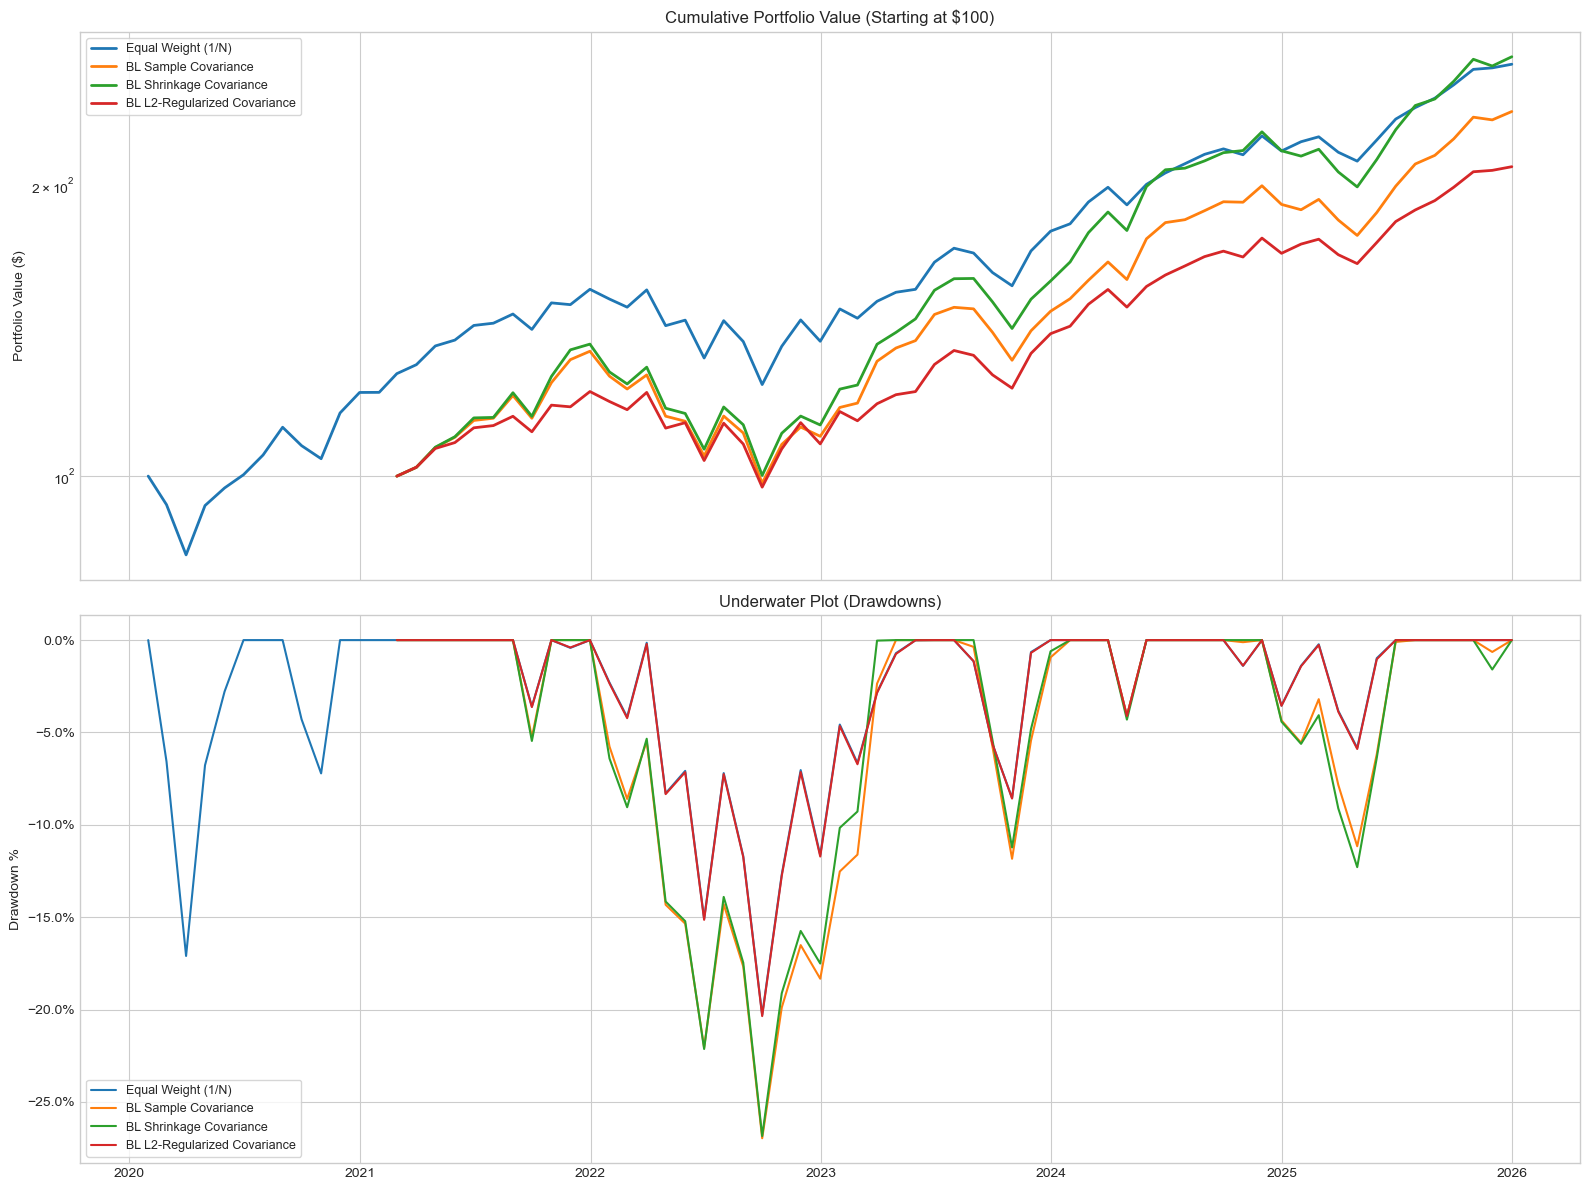

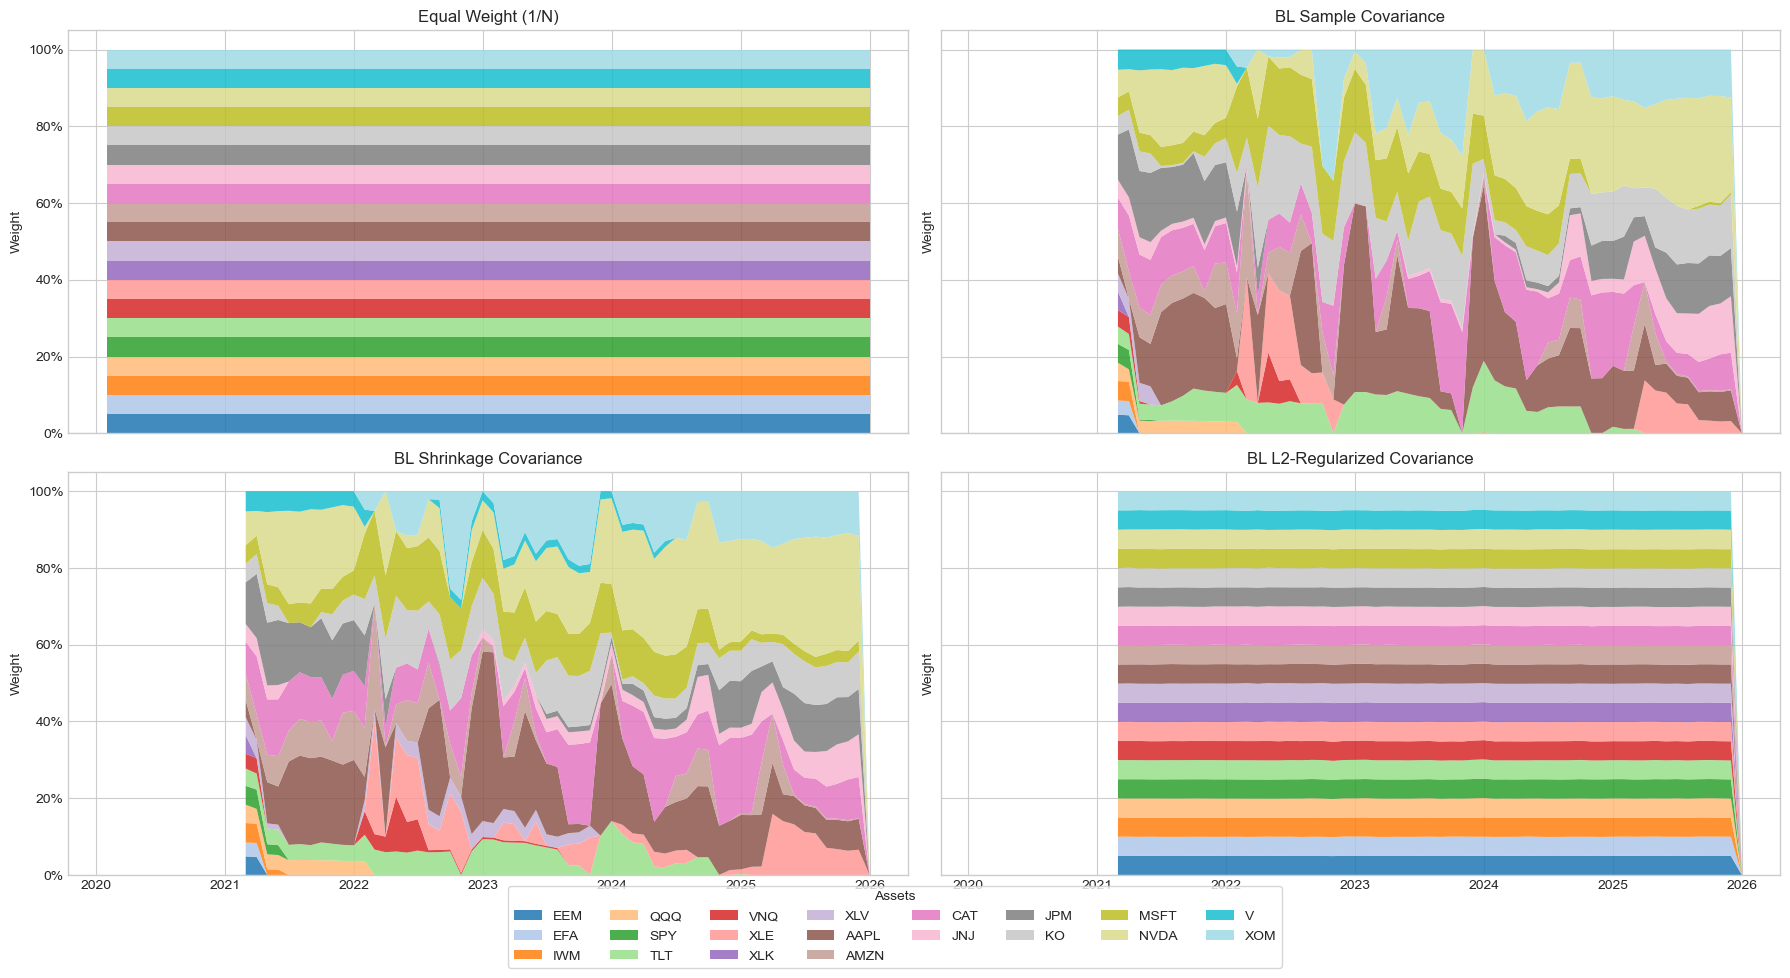

In [15]:
export_results(
    report_df=report_df,
    strategy_results=strategy_results,
    result_dir=config.result_dir,
)

report_df.round(6).to_csv('covariance_backtest2_metrics.csv')
print(f"Saved notebook metrics to covariance_backtest2_metrics.csv")
print(f"Saved engine outputs to {config.result_dir}/")


In [16]:
latest_weights = pd.DataFrame(
    {
        strategy: result['weights'].iloc[-1]
        for strategy, result in strategy_results.items()
    }
)

latest_weights.round(4)


,Equal Weight (1/N),BL Sample Covariance,BL Shrinkage Covariance,BL L2-Regularized Covariance
EEM,0.05,0.0,0.0,0.0
EFA,0.05,0.0,0.0,0.0
IWM,0.05,0.0,0.0,0.0
QQQ,0.05,0.0,0.0,0.0
SPY,0.05,0.0,0.0,0.0
TLT,0.05,0.0,0.0,0.0
VNQ,0.05,0.0,0.0,0.0
XLE,0.05,0.0,0.0,0.0
XLK,0.05,0.0,0.0,0.0
XLV,0.05,0.0,0.0,0.0
